# RPS notebook

1. get data

    Get dataset, create labels csv file, create Dataset/Dataloaders. 

* TODO: image augmentation transformations for training. 

    * PROBLEM: Torch dataset split returns subset object which has no way of adding transforms

2. training
* Torch Example CNN 
* * Ubuntu crashes when using this with live image feed. [Link](https://www.slingacademy.com/article/efficient-pytorch-inference-for-real-time-neural-network-classification/) to ways to make it efficient for real time use.
* ConvNext
* Mediapipe

In [3]:
# imports
import os
import csv
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2

import torch.optim as optim

# Set device to gpu if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")


running on cuda:0


## Data



In [4]:
# Data in file structure

if not os.path.isdir("rps_data_sample") :
    !wget https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/rps_data_sample.zip
    !unzip rps_data_sample.zip
    !rm rps_data_sample.zip
    with open("labels.csv", "w") as labels_csv :
        writer = csv.writer(labels_csv)
        for i, d in enumerate(os.listdir("rps_data_sample")) :
            for f in os.listdir(f"rps_data_sample/{d}") :
                writer.writerow([f"{d}/{f}", i])

Labels = ["Rock", "Scissors", "None", "Paper"]


--2026-04-24 16:49:47--  https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/rps_data_sample.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.128.207, 74.125.143.207, 173.194.69.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.128.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12332447 (12M) [application/zip]
Saving to: ‘rps_data_sample.zip’

rps_data_sample.zip 100%[===================>]  11.76M  12.5MB/s    in 0.9s    

2026-04-24 16:49:48 (12.5 MB/s) - ‘rps_data_sample.zip’ saved [12332447/12332447]

Archive:  rps_data_sample.zip
   creating: rps_data_sample/
   creating: rps_data_sample/paper/
   creating: rps_data_sample/rock/
   creating: rps_data_sample/scissors/
   creating: rps_data_sample/none/
  inflating: rps_data_sample/paper/77.jpg  
  inflating: rps_data_sample/paper/837.jpg  
  inflating: rps_data_sample/paper/176.jpg  
  inflating: rps_data_sample/paper/406.jpg  
  inflatin

number of images: 500


[]

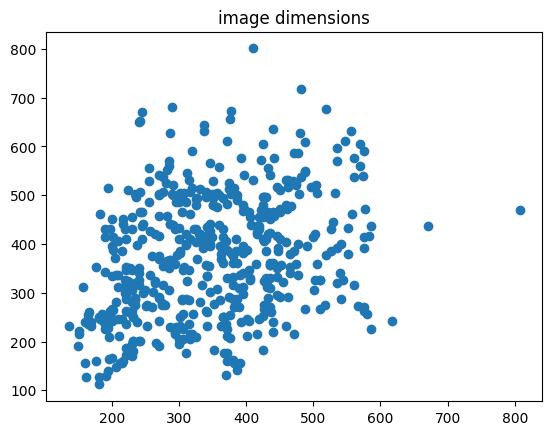

In [5]:
# Check image shapes

import matplotlib.pyplot as plt

im_paths = pd.read_csv("labels.csv", header = None)
im_paths = im_paths.iloc[:,0]

xs , ys = ([], [])
im_count = 0
for path in im_paths :
    im_count += 1
    path = "rps_data_sample/" + str(path)
    im = decode_image(path)
    x = im.shape[1]
    y = im.shape[2]
    xs.append(x)
    ys.append(y)

print(f"number of images: {im_count}")
plt.scatter(xs,ys)
plt.title("image dimensions")
plt.plot()


In [6]:
class RPS_Dataset(Dataset) :
    def __init__(self, labels_file_path : str, data_path : str, transform : v2.Compose | None = None) -> None:
        self._entries = pd.read_csv(labels_file_path, header = None)
        self._dataDir = data_path
        self._transform = transform

    def __len__(self) -> int:
        return len(self._entries)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        item_path = os.path.join(self._dataDir, str(self._entries.iloc[index, 0]))
        item = decode_image(item_path)
        if self._transform :
            item = self._transform(item)
        # How to make label of type int? 
        # or what is the type of Scalar
        label = self._entries.iloc[index, 1]
        return item, label
    
    def set_transform(self, transform : v2.Compose) :
        self._transform = transform
    
#Transforms training with centercrop 600x600 went best
transforms = v2.Compose([
    v2.CenterCrop([600, 600]), # Pads (with 0) small ims and crops large ims 
    #Normalization
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# TODO Random transforms for training

# Random augmentations for training
transforms_train = v2.Compose([
    v2.RandAugment() ,
    v2.CenterCrop([600, 600]),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# For testing no random augmentations
transforms_test = v2.Compose([
    v2.CenterCrop([600,600]),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
    
dataset = RPS_Dataset(labels_file_path="labels.csv", data_path="rps_data_sample", transform= transforms)
train, val = random_split(dataset, [0.8, 0.2])

rps_train_Loader = DataLoader(train, batch_size=64, shuffle=True)
rps_val_Loader = DataLoader(val, batch_size=64, shuffle=True)

## Training

## Simple Torch CNN Example 

[Torch CNN example](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)

(accuracy of about 70%)

In [7]:
# Torch CNN example

from torch import nn
import torch.nn.functional as F

class RPS_Classifier_torch(nn.Module): 
    def __init__(self, n_classes : int, channels : int = 3, dims : tuple[int, int] = (600, 600)) -> None:
        super().__init__()
        x = int(dims[0]/2/2 - 3)
        y = int(dims[1]/2/2 - 3)
        self.conv1 = nn.Conv2d(channels, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * x * y, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, n_classes)

    def forward(self, item : torch.Tensor): 
        x = self.pool(F.relu(self.conv1(item)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [8]:
# define net + hyper params

net = RPS_Classifier_torch(4, dims=(600,600))
net = net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# Training Loop

net.train()
for epoch in range(20):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(rps_train_Loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    print(f'Epoch {epoch} loss: {running_loss :.3f}')

print('Finished Training')

Epoch 0 loss: 9.654
Epoch 1 loss: 9.518
Epoch 2 loss: 8.932
Epoch 3 loss: 7.969
Epoch 4 loss: 7.199
Epoch 5 loss: 7.410
Epoch 6 loss: 6.480
Epoch 7 loss: 5.815
Epoch 8 loss: 5.855
Epoch 9 loss: 4.803
Epoch 10 loss: 4.302
Epoch 11 loss: 3.620
Epoch 12 loss: 3.394
Epoch 13 loss: 3.381
Epoch 14 loss: 2.503
Epoch 15 loss: 2.020
Epoch 16 loss: 1.643
Epoch 17 loss: 1.429
Epoch 18 loss: 1.233
Epoch 19 loss: 1.789
Finished Training


In [9]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
net.eval()
with torch.no_grad():
    for data in rps_val_Loader:
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images: {100 * correct // total} %')

Accuracy of the network on the test images: 72 %


In [11]:
#Save model
torch.save(net.state_dict(), "model.pt")

# If training on google colab gpu :
try :
    from google.colab import files
    files.download("model.pt")
except :
    print("Not on google colab")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ConvNext

In [20]:
# pretrained Convnext

from torchvision import models

convnet = models.convnext_tiny(weights= models.ConvNeXt_Tiny_Weights.DEFAULT)
convnet

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:04<00:00, 25.9MB/s] 


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [21]:
a = dataset[3][0]
print(a)
convnet(a[None, :, :, :])

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

tensor([[-1.3990e+00,  4.4827e-01,  1.1969e-01, -2.5206e-01,  8.5265e-01,
         -2.3304e-01, -8.4365e-01, -5.4923e-01, -7.9611e-01, -6.3403e-01,
         -9.5556e-01, -1.6591e+00, -1.2497e+00, -1.1664e+00, -2.0807e+00,
         -1.4731e+00, -1.3795e+00, -2.1468e+00, -1.3644e+00, -1.4684e+00,
         -1.8681e+00,  1.1519e+00,  6.0106e-01,  1.9696e-01, -1.2103e+00,
         -1.2754e+00, -4.1101e-01, -1.0030e+00, -6.9425e-01,  1.2578e-01,
         -1.0995e+00,  3.4931e-01, -4.6941e-01, -3.3223e-01,  2.7907e-01,
         -1.3185e+00, -8.2730e-01, -1.5587e+00,  8.9087e-01, -1.4385e+00,
         -6.2172e-01, -1.4803e+00, -8.8526e-01, -5.9589e-01, -9.0836e-01,
         -7.0908e-01, -5.6456e-01, -3.1645e-01, -1.3757e+00, -1.1641e+00,
         -1.4321e+00, -3.1995e-02,  4.8882e-01,  4.8334e-01, -3.3505e-01,
         -7.9115e-01, -1.3713e+00, -1.5760e+00, -1.1636e+00,  3.8277e-01,
          3.6716e-01, -1.1934e+00, -1.1112e+00,  5.4523e-01, -2.5028e-01,
         -5.8136e-01, -1.3225e-01, -1.